# ML-KEM (CRYSTALS-Kyber) 강의 노트북
## 격자 기반 키 캡슐화 메커니즘 (Module-Lattice-Based Key Encapsulation Mechanism, FIPS 203)

---

이 노트북은 **미국 표준(NIST)으로 확정된 양자내성 키교환 도구, ML-KEM(CRYSTALS-Kyber)을 처음 배우는
사람**을 위한 강의 자료입니다. 수학을 전공하지 않았어도 따라올 수 있도록, 수식보다는 **비유와 실험
결과**로 설명합니다. KEM이 무엇인지 → 장난감 크기의 Mini-Kyber를 직접 만들어 보고 → 500번 반복
실험으로 확인하고 → 이전 방식(Regev)과 짐의 크기를 비교하고 → 실제 인터넷에서 어떻게 쓰이는지
순서로 진행합니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 ML-KEM 주제를 분리·정리한 강의 자료입니다.
> 실행 셀과 출력은 원본 그대로이며, 재실행하려면 **0장(Setup)의 공통 설정 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. KEM(키 캡슐화 메커니즘 — 공개키로 "공통 비밀 열쇠"를 안전하게 나눠 갖는 절차)이 무엇이고, 왜 지금 인터넷의 키교환을 대체하는지 이해한다.
2. 숫자를 낱개로 다루던 이전 방식(Regev)을 **숫자 묶음(다항식)** 으로 바꾼 Module-LWE의 아이디어를 감으로 잡는다.
3. 열쇠 만들기(KeyGen) / 상자에 담아 보내기(Encaps) / 상자 열기(Decaps) 세 절차를 코드로 직접 확인한다.
4. 500회 반복 실험으로 "양쪽이 같은 비밀을 얻는가", "공격자는 못 여는가"를 검증한다.
5. 비밀 1비트당 보내야 하는 데이터 크기를 비교해, 묶음 처리의 효율 이득을 숫자로 확인한다.
6. FIPS 203 표준 현황과 실제 배포 상황(TLS 하이브리드)을 파악한다.

> **선행 지식**: 01 노트북(또는 통합본 4절)에서 "잡음을 섞어 비밀을 숨기는 LWE 아이디어"를 한 번
> 봤다면 충분합니다. 나머지 연산은 등장할 때마다 그 자리에서 풀어 설명합니다.

## 0. 준비 (Setup)

아래 공통 설정 셀(Harness)은 이 강의 시리즈 전체가 함께 쓰는 실험 도구 상자입니다. 매번 같은 실험
결과가 나오도록 하는 난수 시드(`RNG` — 주사위를 항상 같은 순서로 굴리게 고정하는 장치),
그래프 한글 폰트 설정, 해시 헬퍼(`H`, `shake` — 어떤 값이든 일정한 길이의 "지문"으로 바꿔 주는 도구로,
KEM의 공유비밀을 만들 때 사용), 전송량 측정 함수 `nbytes`, 시간 측정 함수 `timeit`,
실험 수치 기록장 `METRICS`를 정의합니다. **이 노트북의 다른 셀을 실행하기 전에 반드시 이 셀을 먼저
실행해야 합니다.**

> 그래프(matplotlib) 안의 텍스트는 폰트 호환을 위해 영어로 표기합니다.

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. KEM과 Module-LWE 이론

### 1-1. KEM이란 무엇인가

**KEM(Key Encapsulation Mechanism, 키 캡슐화 메커니즘)** 은 멀리 있는 두 사람이 "둘만 아는 비밀
열쇠"를 안전하게 나눠 갖는 절차입니다. 비유로 먼저 보면 이렇습니다.

> 앨리스가 **자물쇠(공개키 — 누구나 볼 수 있는 잠금 장치)** 를 공개해 둡니다.
> 밥은 **무작위 비밀**을 하나 뽑아 상자에 담고, 앨리스의 자물쇠로 잠가 보냅니다(**캡슐화** — 비밀을
> 상자에 담아 잠그는 일). 이 상자는 **열쇠(비밀키 — 앨리스만 가진 여는 장치)** 를 가진 앨리스만
> 열 수 있습니다(**역캡슐화** — 상자를 여는 일). 결과적으로 두 사람은 같은 비밀을 갖게 되고,
> 이것이 **공유비밀(둘만 아는 공통 암호 열쇠)** 이 됩니다.

지금 브라우저가 HTTPS(주소창의 자물쇠 아이콘) 접속을 할 때마다 하는 일이 바로 이것입니다. KEM은
그 일을 **양자컴퓨터가 나와도 안전하게** 하도록 바꾼 것으로, 인터넷 보안 규약(TLS)에서 기존
키교환(Diffie-Hellman/ECDH)의 자리를 대체합니다.

### 1-2. Regev에서 Module-LWE로

ML-KEM의 안전 원리는 01 노트북의 Regev 암호와 같습니다. "작은 잡음을 섞어 비밀을 숨기면, 비밀키
없이는 잡음을 걷어낼 수 없다"는 LWE 아이디어입니다. 달라진 점은 하나, **숫자를 낱개로 다루지 않고
묶음(다항식)으로 처리한다**는 것입니다. 택배를 낱개로 보내는 대신 상자에 여러 개를 담아 한 번에
보내면 포장과 운송비가 줄어드는 것처럼, 곱셈 한 번에 숫자 여러 개가 한꺼번에 처리되어 계산과
전송량이 크게 줄어듭니다. 이렇게 묶음 위에서 정의한 문제를 **Module-LWE**라고 부릅니다.

절차는 세 단계이며, 핵심 수식은 열쇠 만들기 한 줄만 보면 충분합니다.

$$ \mathbf{t} = A\mathbf{s} + \mathbf{e} $$

> **수식 풀이:** $A$는 누구나 볼 수 있는 무작위 표(공개 재료), $\mathbf{s}$는 앨리스만 아는
> 비밀(비밀키), $\mathbf{e}$는 일부러 섞는 작은 잡음입니다. 이 셋을 조합한 결과 $\mathbf{t}$를
> $A$와 함께 공개키(자물쇠)로 공개합니다. 잡음 $\mathbf{e}$ 때문에 $\mathbf{t}$만 보고
> $\mathbf{s}$를 역산할 수 없다는 것이 안전성의 핵심입니다.

- **KeyGen(키 생성)**: 위 식으로 자물쇠(공개키)와 열쇠(비밀키)를 만듭니다.
- **Encaps(캡슐화)**: 밥이 무작위 비밀 $m$을 뽑아, 공개키와 새 잡음을 버무려 두 개의 값(암호문)을
  만들어 보냅니다. 밥 쪽 공유비밀은 $m$의 해시(지문) 값입니다.
- **Decaps(역캡슐화)**: 앨리스가 비밀키로 잡음을 걷어내 같은 $m$을 복원하고, 같은 해시를 계산합니다.

> **핵심 직관**: 보내는 쪽은 비밀을 잡음 속에 숨겨 보내고, 받는 쪽은 비밀키로 잡음을 걷어내 같은
> 비밀을 복원합니다 — 그래서 양쪽이 같은 열쇠를 갖게 됩니다. 잡음이 충분히 작게 설계되어 있어
> 복원은 항상 성공합니다.

### 1-3. 실험 설계 — Mini-Kyber

실제 Kyber는 한 묶음에 숫자 256개를 담습니다. 이 노트북에서는 원리를 눈으로 보기 쉽게 묶음 크기를
16개로 줄인 **Mini-Kyber**를 만들되, 나머지 핵심 설정(나머지 연산의 기준 수 3329, 묶음 개수 2)은
실제 **Kyber-512와 동일**하게 유지합니다. 검증 목표는 두 가지입니다.

1. 두 참여자가 **완전히 같은 공유비밀**을 얻는가 (반복 실험으로 일치율 측정)
2. 공격자가 엉뚱한 비밀키로 상자를 열면 같은 비밀을 **얻을 수 없는가**

아래 셀은 묶음(다항식) 곱셈 `kpmul`과 KeyGen/Encaps/Decaps를 구현한 뒤, 500회 반복으로
공유비밀 일치와 위조 키 실패를 검증하고 키·암호문 크기를 측정합니다.

In [10]:
# ③ 밑바닥 구현 — Mini-Kyber (Module-LWE KEM)
KN, KQ, KK, KETA = 16, 3329, 2, 2   # 차수 / 소수 모듈러스(=Kyber) / 모듈차원(=Kyber-512) / 오차폭

def kpmul(a, b):
    """R_q = Z_q[X]/(X^N+1) 위 다항식 곱셈 (X^N = -1 로 접기)"""
    r = np.zeros(2 * KN - 1, dtype=np.int64)
    for i in range(KN):
        r[i:i + KN] += a[i] * b
    out = r[:KN].copy()
    out[:KN - 1] -= r[KN:2 * KN - 1]
    return out % KQ
kadd = lambda a, b: (a + b) % KQ
ksub = lambda a, b: (a - b) % KQ
ksmall = lambda rng: rng.integers(-KETA, KETA + 1, size=KN) % KQ

def kmatvec(Amat, s):     # A · s
    return [np.sum([kpmul(Amat[i][j], s[j]) for j in range(KK)], axis=0) % KQ for i in range(KK)]
def kmatvec_T(Amat, s):   # A^T · s
    return [np.sum([kpmul(Amat[j][i], s[j]) for j in range(KK)], axis=0) % KQ for i in range(KK)]

def kyber_keygen(rng):
    Amat = [[rng.integers(0, KQ, size=KN) for _ in range(KK)] for _ in range(KK)]
    s = [ksmall(rng) for _ in range(KK)]
    e = [ksmall(rng) for _ in range(KK)]
    t = [kadd(kmatvec(Amat, s)[i], e[i]) for i in range(KK)]
    return (Amat, t), s

def kencode(bits): return (np.array(bits) * (KQ // 2)) % KQ
def kdecode(poly):
    c = np.where(poly > KQ // 2, poly - KQ, poly)
    return (np.abs(c) > KQ // 4).astype(int)

def kyber_encaps(pk, rng):
    Amat, t = pk
    m = rng.integers(0, 2, size=KN)                       # 공유비밀의 씨앗
    r  = [ksmall(rng) for _ in range(KK)]
    e1 = [ksmall(rng) for _ in range(KK)]
    e2 = ksmall(rng)
    u = [kadd(kmatvec_T(Amat, r)[i], e1[i]) for i in range(KK)]
    tr = np.sum([kpmul(t[i], r[i]) for i in range(KK)], axis=0) % KQ
    v = kadd(kadd(tr, e2), kencode(m))
    ss = H(m.astype(np.int64).tobytes())                  # 공유비밀 = H(m)
    return (u, v), ss

def kyber_decaps(sk, ct):
    s = sk; u, v = ct
    su = np.sum([kpmul(s[i], u[i]) for i in range(KK)], axis=0) % KQ
    m2 = kdecode(ksub(v, su))
    return H(m2.astype(np.int64).tobytes())

# ④ 검증 — 500회: 두 참여자가 같은 공유비밀을 얻는가 + 위조 키로는 실패하는가
ok = 0; wrong_key_ok = 0; T = 500
for _ in range(T):
    pk, sk = kyber_keygen(RNG)
    ct, ss_alice = kyber_encaps(pk, RNG)
    ss_bob = kyber_decaps(sk, ct)
    ok += (ss_alice == ss_bob)
    _, sk_eve = kyber_keygen(RNG)                          # 공격자의 엉뚱한 비밀키
    wrong_key_ok += (kyber_decaps(sk_eve, ct) == ss_alice)
print(f'공유비밀 일치(정상): {ok}/{T} = {ok/T:.3f}')
print(f'엉뚱한 비밀키로 같은 비밀 획득(공격 성공): {wrong_key_ok}/{T}  → 0 이어야 안전')
print(f'공개키 ~{nbytes(pk)} B, 암호문 ~{nbytes(ct)} B, 공유비밀 {len(ss_alice)} B')

공유비밀 일치(정상): 500/500 = 1.000
엉뚱한 비밀키로 같은 비밀 획득(공격 성공): 0/500  → 0 이어야 안전
공개키 ~768 B, 암호문 ~384 B, 공유비밀 32 B


### 1-4. 검증 결과 읽기

출력을 확인하면 다음과 같습니다.

- **공유비밀 일치 500/500 (= 1.000)**: 500회 모두 보내는 쪽(Encaps)과 여는 쪽(Decaps)이 같은
  32바이트 공유비밀을 얻었습니다. 섞어 놓은 잡음이 "복원 가능한 한계선"(기준 수 $q$의 4분의 1)을
  한 번도 넘지 않아, 숨긴 비밀이 매번 정확히 복원된 것입니다.
- **엉뚱한 비밀키 성공 0/500**: 공격자가 자기 비밀키로 상자를 열면 잡음을 걷어내지 못해 전혀 다른
  값이 나옵니다. 0회여야 안전하며, 실제로 0회입니다.
- **크기**: 공개키 약 768 B, 암호문 약 384 B, 공유비밀 32 B(SHA-256 해시 출력).

**KEM으로서 정확성(양쪽 일치)과 기본 안전성(위조 키 실패)이 동시에 확인되었습니다.**

## 2. Regev 대비 효율 — 다항식 구조의 힘

Regev와 Mini-Kyber는 **같은 LWE 안전 원리**를 씁니다. 그런데 숫자를 묶음(다항식)으로 처리하면
"비밀 1비트를 보내는 데 드는 짐의 크기"가 얼마나 줄어들까요? 이 절에서는 두 방식의 **비트당
암호문 크기**를 직접 비교합니다.

다음 셀은 분리 노트북 보완 셀로, 통합 노트북 4절(Regev/LWE)에서 실제로 측정한 값(공개키 약 2304 B,
암호문 65 B/비트)을 기록장 `METRICS`에 등록하여 이 노트북만으로도 비교 셀이 실행되도록 합니다.

In [ ]:
# 🔗 [분리 노트북 보완] 아래 비교 셀은 통합 노트북 4절(Regev/LWE)의 실측값을 참조합니다.
# 분리 실행 시에도 동작하도록, 통합 노트북 v3 실행 출력(공개키 ~2304 B, 암호문 ~65 B/비트)을 등록합니다.
METRICS.setdefault('Regev/LWE', {'pk_bytes': 2304, 'ct_bytes': 65})
print('Regev/LWE 실측값 등록:', METRICS['Regev/LWE'])

### 2-1. 비트당 암호문 크기 시각화

아래 셀은 Regev가 비밀 1비트를 보낼 때 드는 암호문 크기(`METRICS`에 등록된 실측값)와 Mini-Kyber의
1비트당 암호문 크기(전체 암호문 크기를 한 번에 실어 보내는 비트 수로 나눈 값)를 막대그래프로
비교하고, Mini-Kyber의 수치를 `METRICS`에 기록합니다.

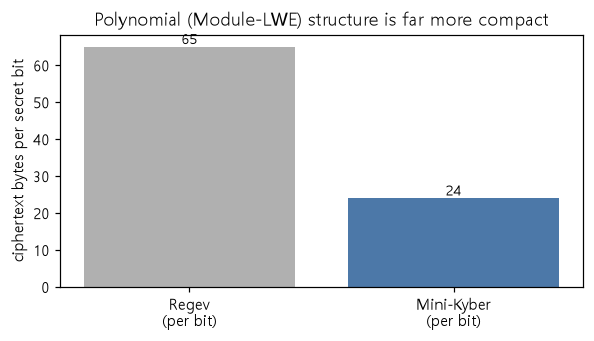

In [11]:
# 비트당 암호문 크기 비교 (개념 비교이므로 대략치)
regev_ct_per_bit = METRICS['Regev/LWE']['ct_bytes']            # 1비트당
kyber_ct_total   = nbytes(ct)                                  # KN비트 씨앗 → 공유비밀
kyber_ct_per_bit = kyber_ct_total / KN
labels = ['Regev\n(per bit)', 'Mini-Kyber\n(per bit)']
vals = [regev_ct_per_bit, kyber_ct_per_bit]
fig, ax = plt.subplots(figsize=(5.5, 3.2))
bars = ax.bar(labels, vals, color=['#B0B0B0', '#4C78A8'])
ax.set_ylabel('ciphertext bytes per secret bit')
ax.set_title('Polynomial (Module-LWE) structure is far more compact')
for b_, v in zip(bars, vals):
    ax.text(b_.get_x()+b_.get_width()/2, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
log_metric('ML-KEM (Kyber)', pk_bytes=nbytes(pk), ct_bytes=nbytes(ct), ss_bytes=len(ss_alice), match=ok/T)

### 2-2. 결과 해석

막대 위 숫자를 보면 **Regev는 1비트당 65바이트, Mini-Kyber는 24바이트**입니다.
같은 LWE 원리인데 전송량이 **1/3 이하**로 줄었습니다.

이 차이는 포장 방식에서 옵니다. Regev는 비트 하나마다 숫자 꾸러미를 통째로 보내는 "낱개 배송"인
반면, Kyber는 다항식이라는 상자에 여러 비트를 한꺼번에 담아 보내는 "묶음 배송"입니다. 같은 물건을
보내도 포장 단위가 크면 개당 운송비가 내려가는 것과 같은 이치입니다.

> **바로 이 포장 방식의 차이가 Kyber를 실제 인터넷에서 쓸 수 있게 만든 핵심입니다.**

### 2-3. 실무 적용성

- **측정**: 500/500 공유비밀 일치, 엉뚱한 비밀키로는 0회 성공 — KEM이 올바르게 동작합니다.
  묶음(다항식) 구조 덕분에 비트당 전송량이 Regev 대비 급감했습니다(65 B → 24 B).
- **표준**: **FIPS 203 (ML-KEM)** 이라는 이름의 미국 연방 표준으로 **2024년 8월 확정**되었습니다.
  실제 권장 파라미터인 Kyber-768의 공개키는 약 1184 B, 암호문은 약 1088 B — 기존 RSA-3072(공개키
  약 384 B)보다 크지만 충분히 실용적입니다.
- **적합처**: **TLS 키교환, VPN, 메신저 세션키** — 지금 Diffie-Hellman/ECDH를 쓰는 모든 곳입니다.
  이미 TLS 1.3에 기존 방식과 나란히 쓰는 하이브리드(X25519 + ML-KEM) 방식으로 배포되고 있습니다.
- **주의**: 실제 표준은 여기에 **Fujisaki-Okamoto 변환**이라는 안전장치를 더합니다. 받은 상자를
  자기 손으로 다시 잠가 보고, 받은 것과 똑같은지 확인한 뒤에만 결과를 내놓는 절차로, 교묘하게 조작된
  상자로 비밀키 정보를 캐내는 공격을 막습니다. 이 노트북은 그 핵심 골격만 보여 준 것입니다.

> **정리**: Kyber(ML-KEM)는 "양자 시대의 키교환"으로 이미 확정·배포 중인 표준이며, 원리는
> LWE(Regev)의 잡음 아이디어에 묶음(다항식) 포장을 입힌 것입니다.

## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요.

1. **묶음 개수 늘리기**: `KK`를 2에서 3으로 바꿔(실제 Kyber-768에 대응) 다시 실행해 보세요.
   공개키(~768 B)와 암호문(~384 B) 크기가 각각 어떻게 변하나요? 공개 재료 표가 가로·세로 모두
   묶음 개수만큼 커진다는 점에서 공개키 증가 폭을 예측한 뒤 `nbytes` 출력과 비교해 보세요.

2. **잡음 크기와 복원 실패**: 잡음 크기 `KETA`를 2에서 6, 10 등으로 키우면서 공유비밀
   일치율(500/500)이 언제부터 무너지는지 관찰하세요. "복원 가능한 한계선이 기준 수의 4분의 1"이라는
   사실과 연결해 설명해 보세요.

3. **묶음 크기와 비트당 효율**: 한 묶음에 담는 숫자 개수 `KN`을 16에서 32, 64로 바꾸면 1비트당
   암호문 크기(현재 24 B)는 어떻게 되나요? 전체 암호문 크기와 한 번에 실어 보내는 비트 수가 함께
   늘어난다는 점을 이용해 결과를 미리 계산해 보고 그래프로 확인하세요.

4. **검증 횟수 확장**: 반복 횟수 `T`를 500에서 5000으로 늘려도 일치율 1.000과 위조 키 성공 0회가
   유지되는지 확인하고, `timeit`으로 KeyGen/Encaps/Decaps 각각의 실행 시간을 측정해 보세요.

## 요약

- KEM은 공개키(자물쇠)로 **공유 비밀키를 안전하게 나눠 갖는** 도구이며, 인터넷 보안 규약(TLS)에서 기존 Diffie-Hellman 키교환의 자리를 대체한다.
- ML-KEM(Kyber)은 Regev(LWE)의 "잡음으로 비밀 숨기기" 원리를 그대로 쓰되, 숫자를 낱개 대신 **묶음(다항식)** 으로 처리하는 **Module-LWE** 기반이다.
- 묶음 크기만 줄인 Mini-Kyber 구현으로 **500/500 공유비밀 일치, 위조 키 성공 0회**를 확인했다
  (공개키 ~768 B, 암호문 ~384 B, 공유비밀 32 B).
- 묶음 포장 덕분에 비트당 암호문이 Regev 65 B → Mini-Kyber 24 B로 **1/3 이하**로 줄었다 — 격자 암호 실용화의 핵심.
- **FIPS 203**으로 2024년 8월 확정되었고, TLS 1.3 하이브리드(X25519 + ML-KEM)로 이미 배포 중이다.
- 실제 표준은 여기에 **Fujisaki-Okamoto 변환**(상자를 다시 잠가 비교하는 안전장치)을 더해 부채널·키 재사용 공격까지 방어한다.

> 다음 노트북(03 ML-DSA)에서는 같은 격자 문제 위에서 **서명**(문서에 하는 위조 불가능한 도장)을
> 만드는 방법을 다룹니다. 키교환(ML-KEM)과 서명(ML-DSA)이 합쳐져야 양자 시대의 TLS가 완성됩니다.